In [1]:
import sys, os

sys.path.insert(0, os.path.abspath(".."))
sys.path.insert(0, os.path.abspath("helper"))

from plot_utils import (
    np,
    plt,
    save_figure,
    FIGURE_SIZE_HALF,
    GRID_STYLE,
    slate_teal,
    deep_red,
    warm_orange,
    plum,
    sage,
    navy,
    bordeaux,
)
from manager.services.indicator_service import compute_indicators
from manager.models.config_models import ExperimentConfig

FIG_DIR = "../figures/evaluation/scalability"
os.makedirs(FIG_DIR, exist_ok=True)


def sweep(base_kwargs, sweep_param, sweep_values):
    results = []

    for value in sweep_values:
        kwargs = dict(base_kwargs)
        kwargs[sweep_param] = value

        config = ExperimentConfig(**kwargs)
        results.append((value, compute_indicators(config)))

    return results


N_vals = list(range(2, 21))

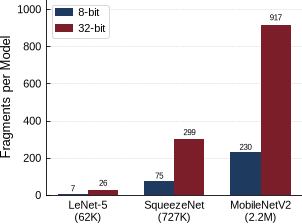

In [2]:
models = ["lenet5", "squeezenet", "mobilenetv2"]
quant_bits = [8, 32]
model_labels = ["LeNet-5\n(62K)", "SqueezeNet\n(727K)", "MobileNetV2\n(2.2M)"]

fig, ax = plt.subplots(figsize=FIGURE_SIZE_HALF)
x = np.arange(len(models))
width = 0.35

ymax = 0
for bar_index, bits in enumerate(quant_bits):

    fragments = []
    for model in models:

        config = ExperimentConfig(model_name=model, quantization_bits=bits)
        indicators = compute_indicators(config)

        fragments.append(indicators["communication"]["fragments_per_model"])

    ymax = max(ymax, max(fragments))

    offset = (bar_index - 0.5) * width

    bars = ax.bar(x + offset, fragments, width, label=f"{bits}-bit", color=[navy, bordeaux][bar_index])

    for bar, fragment_count in zip(bars, fragments):

        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + ymax * 0.015,
            str(fragment_count),
            ha="center",
            va="bottom",
            fontsize=6,
        )

ax.set_xticks(x)
ax.set_xticklabels(model_labels)
ax.set_ylabel("Fragments per Model")
ax.set_ylim(0, ymax * 1.15)

ax.grid(axis="y", **GRID_STYLE)

legend = ax.legend()
legend.get_frame().set_facecolor((1, 1, 1, 1))
fig.tight_layout()

save_figure(fig, f"{FIG_DIR}/fragments_per_model.pdf")
plt.show()

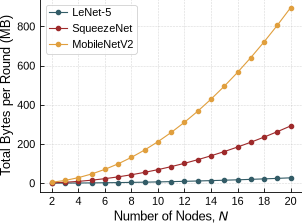

In [3]:
from matplotlib.ticker import MaxNLocator

fig, ax = plt.subplots(figsize=FIGURE_SIZE_HALF)
model_colors = [slate_teal, deep_red, warm_orange]
model_names_display = ["LeNet-5", "SqueezeNet", "MobileNetV2"]

for model, color, name in zip(models, model_colors, model_names_display):

    results = sweep({"model_name": model}, "n_nodes", N_vals)

    x_values = [node_count for node_count, _ in results]
    y_values = [ind["communication"]["bytes_per_round"] / 1e6 for _, ind in results]

    ax.plot(x_values, y_values, marker="o", color=color, label=name, linewidth=0.8, markersize=3)

ax.set_xlabel("Number of Nodes, $N$")
ax.set_ylabel("Total Bytes per Round (MB)")
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
ax.grid(**GRID_STYLE)

legend = ax.legend()
legend.get_frame().set_facecolor((1, 1, 1, 1))

fig.tight_layout()
save_figure(fig, f"{FIG_DIR}/bytes_per_round_vs_n.pdf")
plt.show()

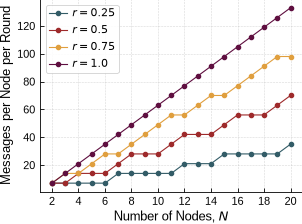

In [4]:
from matplotlib.ticker import MaxNLocator

ratios = [0.25, 0.5, 0.75, 1.0]
ratio_colors = [slate_teal, deep_red, warm_orange, plum]

fig, ax = plt.subplots(figsize=FIGURE_SIZE_HALF)

for ratio, color in zip(ratios, ratio_colors):
    results = sweep({"partial_update_ratio": ratio}, "n_nodes", N_vals)

    x_values = [node_count for node_count, _ in results]
    y_values = [ind["communication"]["messages_per_node"] for _, ind in results]

    ax.plot(x_values, y_values, marker="o", color=color, label=f"$r={ratio}$", linewidth=0.8, markersize=3)

ax.set_xlabel("Number of Nodes, $N$")
ax.set_ylabel("Messages per Node per Round")
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
ax.grid(**GRID_STYLE)

legend = ax.legend()
legend.get_frame().set_facecolor((1, 1, 1, 1))
fig.tight_layout()
save_figure(fig, f"{FIG_DIR}/messages_per_node_ratio.pdf")
plt.show()

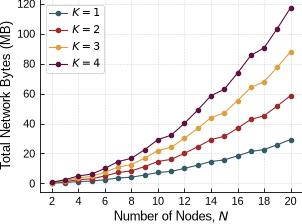

In [5]:
from matplotlib.ticker import MaxNLocator

K_sweep = [1, 2, 3, 4]

fig, ax = plt.subplots(figsize=FIGURE_SIZE_HALF)
k_colors = [slate_teal, deep_red, warm_orange, plum]

for K, color in zip(K_sweep, k_colors):
    results = sweep({"max_hops": K, "model_name": "lenet5"}, "n_nodes", N_vals)

    x_values = [node_count for node_count, _ in results]
    y_values = [ind["mixnet_traffic"]["total_bytes_network"] / 1e6 for _, ind in results]

    ax.plot(x_values, y_values, marker="o", color=color, label=f"$K={K}$", linewidth=0.8, markersize=3)

ax.set_xlabel("Number of Nodes, $N$")
ax.set_ylabel("Total Network Bytes (MB)")
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
ax.grid(**GRID_STYLE)

legend = ax.legend()
legend.get_frame().set_facecolor((1, 1, 1, 1))

fig.tight_layout()
save_figure(fig, f"{FIG_DIR}/total_network_bytes.pdf")
plt.show()